## Imports

The required libraries were imported for data manipulation, numerical operations, and visualization.

- `pandas` is used for loading and organizing the dataset.
- `numpy` is used for numerical calculations.
- `matplotlib` is used for plotting the time series and forecast results.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



## Data Preparation

In this step, the dataset was loaded and filtered to include only JFK Airport observations.

The month values were converted into numerical format, and a proper datetime column was created by combining the year and month information. Then, the datetime column was set as the index of the dataset.

Finally, the **Total Passengers** variable was selected as the target time series for forecasting analysis.

In [ ]:
# Load the dataset, 
df = pd.read_csv('data/air-passenger-traffic-per-month-port-authority-of-ny-nj-beginning-1977.csv')

# filtered only JFK observation 

df = df[df['Airport Code'] == 'JFK'].copy()

# Map month names to manth number

month_map = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "Jun": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
}

df['Month'] = df['Month'].astype(str).str.strip().map(month_map)

# Creat a datetime 

df['Date'] = pd.to_datetime(
    dict(
        year=df['Year'],
        month=df['Month'],
        day=1
    )
) 

# Set  datetime as index 
df.set_index('Date', inplace=True)

# sort by date 
df.sort_index(inplace=True)

# Select the target timeseries 
ts = df['Total Passengers']

ts.head(10)



### Time Series Visualization

The time series plot illustrates the monthly total number of passengers at JFK Airport over time.

From the graph, a clear upward trend can be observed, indicating that the number of passengers has generally increased over the years.

Additionally, recurring patterns can be seen within each year, suggesting the presence of seasonality. These seasonal fluctuations are typical in air transportation data, where passenger volumes tend to increase during certain periods such as summer and holiday seasons.

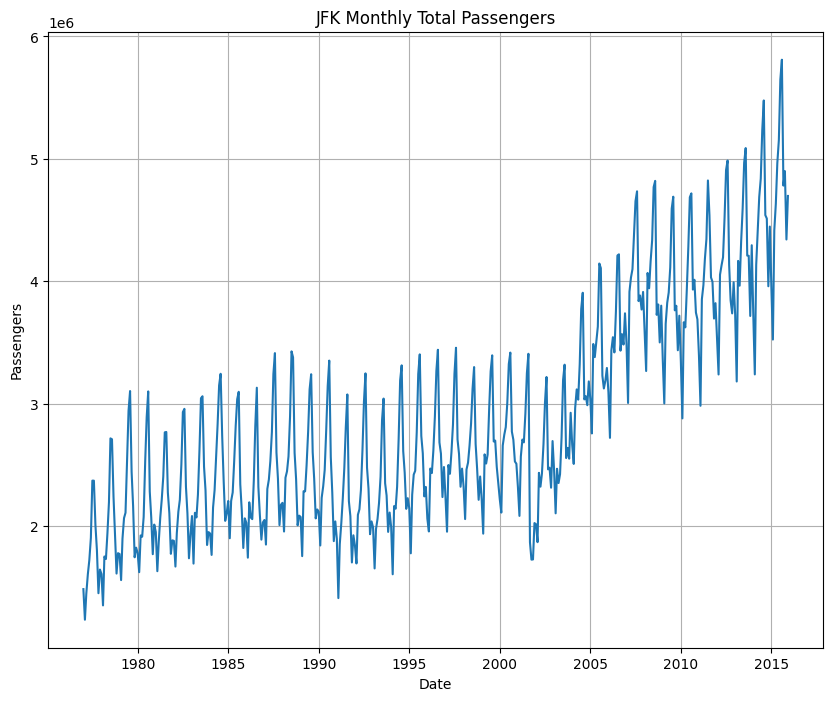

In [13]:
plt.figure(figsize=(10,8))
plt.plot(ts)
plt.title("JFK Monthly Total Passengers")
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.grid(True)
plt.show()


## 2-Period Moving Average Forecast

In this step, a 2-period moving average method was applied to forecast the next period.

For each observation, the forecast value was calculated as the average of the previous two actual observations. Then, the result was shifted by one period so that the forecast corresponds to the next time point.

This method smooths short-term fluctuations and provides a simple baseline forecasting approach.

In [11]:
# 2- period moving average forecast
df_ma = pd.DataFrame({'actual': ts.copy()})

df_ma['MA_2'] = df_ma['actual'].rolling(window=2).mean().shift(1)

df_ma.head(10)


,actual,MA_2
Date,,
1977-01-01,1487588,NaN
1977-02-01,1237719,NaN
1977-03-01,1450395,1362653.5
1977-04-01,1609159,1344057.0
1977-05-01,1724392,1529777.0
1977-06-01,1906396,1666775.5
1977-07-01,2373334,1815394.0
1977-08-01,2372987,2139865.0
1977-09-01,2010979,2373160.5


## 3-Period Moving Average Forecast

A 3-period moving average method was also applied.

Here, each forecast value was calculated using the average of the previous three actual observations. Similar to the 2-period method, the values were shifted by one period to obtain one-step-ahead forecasts.

Compared with the 2-period moving average, this method produces a smoother series but may respond more slowly to sudden changes.

In [15]:
# 3- period moving avarage forecast
df_ma['MA_3'] = df_ma['actual'].rolling(window=3).mean().shift(1)

df_ma.head(10)

,actual,MA_2,MA_3
Date,,,
1977-01-01,1487588,NaN,NaN
1977-02-01,1237719,NaN,NaN
1977-03-01,1450395,1362653.5,NaN
1977-04-01,1609159,1344057.0,1.391901e+06
1977-05-01,1724392,1529777.0,1.432424e+06
1977-06-01,1906396,1666775.5,1.594649e+06
1977-07-01,2373334,1815394.0,1.746649e+06
1977-08-01,2372987,2139865.0,2.001374e+06
1977-09-01,2010979,2373160.5,2.217572e+06


## Forecast Preview

The table below shows the actual values together with the forecasts obtained from the 2-period and 3-period moving average methods.

The first few observations contain missing forecast values because the moving average methods require previous observations before producing a forecast.

In [16]:
df_ma[['actual', 'MA_2', 'MA_3']].head(12)

,actual,MA_2,MA_3
Date,,,
1977-01-01,1487588,NaN,NaN
1977-02-01,1237719,NaN,NaN
1977-03-01,1450395,1362653.5,NaN
1977-04-01,1609159,1344057.0,1.391901e+06
1977-05-01,1724392,1529777.0,1.432424e+06
1977-06-01,1906396,1666775.5,1.594649e+06
1977-07-01,2373334,1815394.0,1.746649e+06
1977-08-01,2372987,2139865.0,2.001374e+06
1977-09-01,2010979,2373160.5,2.217572e+06


## Visualization of Moving Average Forecasts

The graph compares the actual passenger values with the forecasts obtained from the 2-period and 3-period moving average methods.

This visualization helps evaluate how closely each method follows the actual time series. It also shows the smoothing effect of each method and highlights whether the forecasts lag behind the actual pattern.

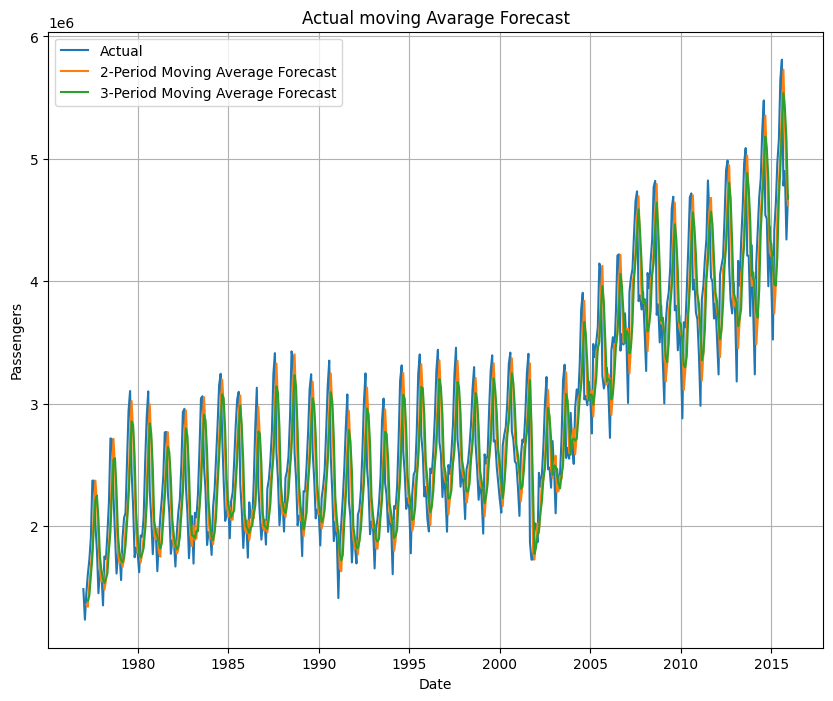

In [20]:
plt.figure(figsize=(10,8))
plt.plot(df_ma.index, df_ma['actual'], label='Actual')
plt.plot(df_ma['MA_2'], label='2-Period Moving Average Forecast')
plt.plot(df_ma['MA_3'], label='3-Period Moving Average Forecast')

plt.title('Actual moving Avarage Forecast')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()


## Recent Period Comparison

A closer view of the last 36 periods was created to better compare the forecast performance of the moving average methods.

Since the full time series is long, focusing on the most recent observations makes it easier to examine how well the forecasts track the actual values.

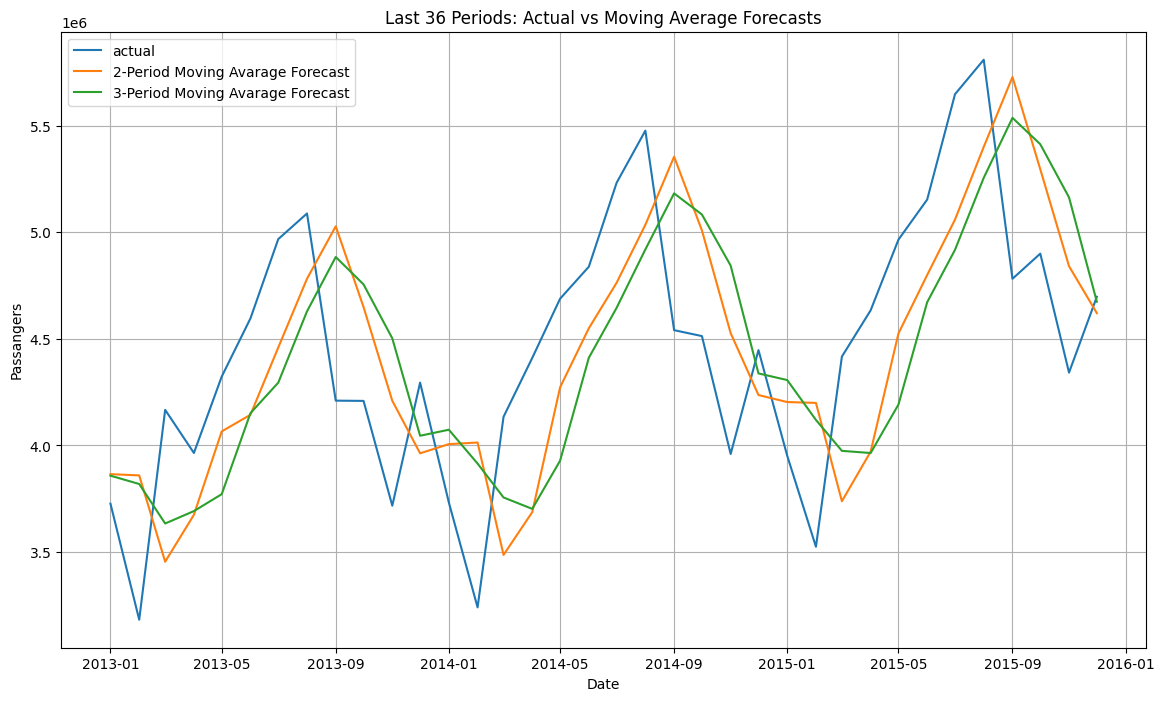

In [21]:
plt.figure(figsize=(14,8))
plt.plot(df_ma.index[-36:], df_ma['actual'].iloc[-36:], label='actual')
plt.plot(df_ma.index[-36:], df_ma['MA_2'].iloc[-36:], label='2-Period Moving Avarage Forecast')
plt.plot(df_ma.index[-36:],df_ma['MA_3'].iloc[-36:], label='3-Period Moving Avarage Forecast' )

plt.title('Last 36 Periods: Actual vs Moving Average Forecasts')
plt.xlabel('Date')
plt.ylabel('Passangers')
plt.grid(True)
plt.legend()
plt.show(
    
)

## One-Step-Ahead Forecast

The next period forecast was calculated using the most recent observations.

- For the 2-period moving average, the forecast was obtained by averaging the last two actual values.
- For the 3-period moving average, the forecast was obtained by averaging the last three actual values.

These values represent the one-step-ahead forecasts required for the assignment.

In [27]:
forecast_ma2_next = ts.iloc[-2:].mean()
forecast_ma3_next = ts.iloc[-3:].mean()

print('Next period forecast with 2- period moving avarage', round(forecast_ma2_next,2))
print('Next period forecast with 3-period moving avarage', round(forecast_ma3_next, 2))

Next period forecast with 2- period moving avarage 4519775.5
Next period forecast with 3-period moving avarage 4646539.0


## Interpretation

The moving average methods provide simple and intuitive forecasts by smoothing past observations.

The 2-period moving average is more responsive to recent changes, while the 3-period moving average produces a smoother forecast. However, both methods may lag behind the actual series, especially when the data contains strong trend and seasonality.